In [9]:
hok_path = '/content/drive/MyDrive/UTY/Semester 7/Pemrosesan Teks /hok_reviews_clean.csv'
mlbb_path = '/content/drive/MyDrive/UTY/Semester 7/Pemrosesan Teks /mlbb_reviews_clean.csv'

In [10]:
import pandas as pd

df_hok = pd.read_csv(hok_path)
df_mlbb = pd.read_csv(mlbb_path)

## Tokenisasi data


In [11]:
import nltk
import pandas as pd
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab', quiet=True)

def tokenize_reviews(review):
  """Tokenizes a given review string."""
  if pd.isna(review):
    return []
  return word_tokenize(review)

df_hok['tokenized'] = df_hok['content_clean'].apply(tokenize_reviews)
df_mlbb['tokenized'] = df_mlbb['content_clean'].apply(tokenize_reviews)

# Filtering

In [12]:
import re

def filter_tokens(tokens):
    """Filters out non-alphabetic characters and repeated letters from a list of tokens."""
    filtered_tokens = []
    # Regex to match any character that is NOT a letter (a-z, A-Z) or a space
    pattern = re.compile(r'[^a-zA-Z\s]+')
    # Regex to match 3 or more repeating characters
    repeat_pattern = re.compile(r'(.)\1{2,}')

    for token in tokens:
        # Remove non-alphabetic characters
        cleaned_token = pattern.sub('', token)
        # Remove repeating characters
        cleaned_token = repeat_pattern.sub(r'\1', cleaned_token)
        if cleaned_token: # Keep only non-empty strings after filtering
            filtered_tokens.append(cleaned_token)
    return filtered_tokens

df_hok['filtered_tokens'] = df_hok['tokenized'].apply(filter_tokens)
df_mlbb['filtered_tokens'] = df_mlbb['tokenized'].apply(filter_tokens)

# Stemming

In [13]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.4 MB/s eta 0:00:00


In [14]:
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import pandas as pd

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    """Stems a list of tokens."""
    return [stemmer.stem(token) for token in tokens]

df_hok['stemmed_tokens'] = df_hok['filtered_tokens'].apply(stem_tokens)
df_mlbb['stemmed_tokens'] = df_mlbb['filtered_tokens'].apply(stem_tokens)

# Slang Words

In [15]:
slang_words = {
      'bagu':'bagus',
      'bgt':'banget',
      'gak':'tidak',
      'gk':'tidak',
      'gw':'aku',
      'trus':'terus',
      'monton':'moonton',
      'montoon':'moonton',
      'maen':'main',
      'leg':'lag',
      'ngelag':'lag',
      'ngeleg':'lag',
      'klo':'kalau',
      'tim':'team',
      'ga':'tidak',
      'lu':'kamu',
      'gem':'game',
      'gua':'aku',
      'saya':'aku',
      'g':'tidak',
      'kalo':'kalau',
      'gin':'game',
      'yg':'yang',
      'ngelek':'lag',
      'sering lag':'lag',
      'kayak':'seperti',
      'kaya':'seperti',
      'geme':'game',
      'i':'aku',
      'ny':'nya',
      'gamenya':'game',
      'x':'kali',
      'dark':'gelap',
      'bener':'benar',
      'benerin':'rusak',
      'dibenerin':'rusak',
      'beneran':'serius',
      'gabener':'salah',
      'benerr':'benar',
      'benerlah':'benar',
      'bbenerin':'rusak',
      'benere':'benar',
      'benerlaa':'benar',
      'ngasih':'beri',
      'udh':'sudah',
      'ni':'ini',
      'karna':'karena',
      'min':'minimal',
      'burik':'buruk',
      'sampe':'sampai',
      'pake':'pakai',
      'drak':'gelap',
      'emang':'memang',
      'dikit':'sedikit',
      'dikitlh':'sedikit',
      'cuman':'hanya',
      'dah':'sudah',
      'berik':'beri',
      'ajha':'aja',
      'kek':'seperti',
      'lapor':'report',
      'laporin':'report',
      'ngelaporin':'report',
      'reportnya':'report',
      'direport':'report',
      'ngreport':'report',
      'cobain':'coba',
      'coban':'coba',
      'temen':'teman',
      'temenya':'teman',
      'temanteman':'teman',
      'temantemanku':'teman',
      'jagoteman':'jago',
      'doang':'hanya',
      'drag':'gelap',
      'system':'sistem',
      'dpt':'dapat',
      'tetep':'tetap',
      'stress':'stres',
      'nggak':'tidak',
      'skil':'skill',
      'skillnya':'skill',
      'skills':'skill',
      'bosok':'buruk',
      'bobrok':'buruk',
      'anjlok':'buruk',
      'toksik':'buruk',
      'kalok':'kalau',
      'ok':'oke',
      'okey':'oke',
      'gue':'aku',
      'baguss':'bagus',
      'anda':'kamu',
      'terimakasi':'terimakasih',
      'terima':'terimakasih',
      'makasihh':'terimakasih',
      'trjmakasih':'terimakasih',
      'trimakasih':'terimakasih',
      'makasih':'terimakasih',
      'tpi':'tapi',
      'aj':'aja',
      'jdi':'jadi',
      'ampas':'buruk',
      'woi':'buruk',
      'tp':'tapi',
      'matchmakingnya':'matchmaking',
      'bet':'banget',
      'ytim':'yatim',
      'sangatt':'sangat',
      'inisangat':'sangat'
}

def replace_slang(tokens, slang_dict):
    """Replaces slang words in a list of tokens using a slang dictionary."""
    return [slang_dict.get(token, token) for token in tokens]

df_hok['slang_replaced'] = df_hok['stemmed_tokens'].apply(lambda x: replace_slang(x, slang_words))
df_mlbb['slang_replaced'] = df_mlbb['stemmed_tokens'].apply(lambda x: replace_slang(x, slang_words))

# Stopwords

In [16]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set([
    'yang', 'nya', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'adalah', 'itu', 'aja', 'tapi', 'sih', 'dapet', 'tiap', 'saat', 'tapi', 'kasih', 'jaring',
    'pas', 'mulu', 'dulu', 'ini', 'saya', 'kami', 'kita', 'anda', 'mereka', 'atau', 'juga', 'tidak', 'eh', 'nyeselin', 'yah', 'ya', 'nah', 'kok', 'lagi', 'udah',
    'jadi', 'karena', 'agar', 'supaya', 'moonton', 'sebagai', 'oleh', 'terhadap', 'tentang', 'bahwa', 'hanya', 'saja', 'masih', 'telah', 'akan', 'bisa', 'dapat',
    'harus', 'boleh', 'mau', 'ingin', 'perlu', 'nya','game', 'hp', 'gamenya', 'tara', 'ml', 'hok', 'ada', 'aku', 'main', 'hero', 'rank', 'team', 'kalau', 'apa',
    'player', 'terus', 'sama', 'lah', 'nge', 'matchmaking', 'match', 'malah', 'download', 'orang', 'padahal', 'making', 'tau', 'plis', 'tencent', 'malah', 'buat',
    'udah', 'seperti', 'bikin', 'sering', 'kali', 'tiap', 'tiba', 'sekali', 'solo', 'data', 'kok', 'ku', 'saat', 'honor', 'of', 'kings', 'legend', 'mobile', 'dong',
    'belah', 'hari', 'tuh', 'kan', 'in', 'mlbb', 'soal', 'pun', 'login', 'waktu', 'kata', 'moba', 'mode', 'pakai', 'the', 'kalian', 'lane', 'sistem', 'nih', 'war',
    'simpan', 'fitur', 'ketika', 'awal', 'pick', 'cara', 'ama', 'gilir', 'nama', 'map', 'to', 'masak', 'gameplay', 'beli', 'loh', 'kesini', 'sini', 'apalagi', 'turut',
    'deh', 'memang', 'kembali', 'baca', 'bakal', 'temu', 'daripada', 'rasa', 'is', 'a', 'si', 's', 'jam', 'tahun', 'liat', 'depan', 'la', 'sangat', 'kamu'
])

def remove_stopwords_nltk(tokens):
    """Removes stopwords from a list of tokens using NLTK's stopword list."""
    if not isinstance(tokens, list):
        return [] # Return empty list for non-list inputs
    return [token for token in tokens if token not in stop_words]

df_hok['stopwords_removed'] = df_hok['slang_replaced'].apply(remove_stopwords_nltk)
df_mlbb['stopwords_removed'] = df_mlbb['slang_replaced'].apply(remove_stopwords_nltk)

In [17]:
df_hok.to_csv(hok_path, index=False)
df_mlbb.to_csv(mlbb_path, index=False)

# Wordclouds

In [18]:
!pip install wordcloud

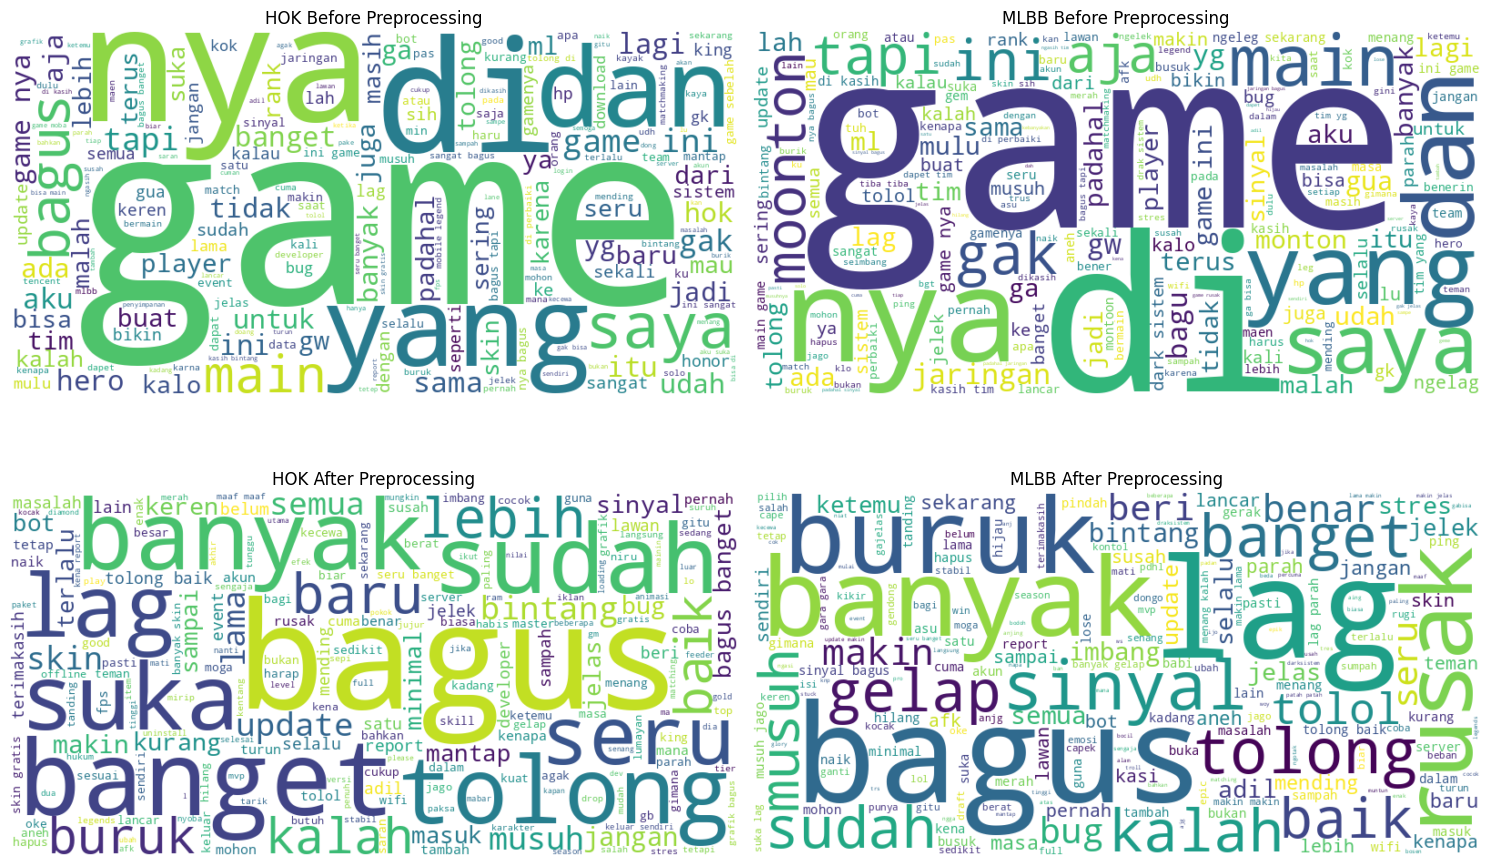

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

hok_before = ' '.join(df_hok['content_clean'].astype(str))
hok_after = ' '.join([' '.join(tokens) for tokens in df_hok['stopwords_removed']])
mlbb_before = ' '.join(df_mlbb['content_clean'].astype(str))
mlbb_after = ' '.join([' '.join(tokens) for tokens in df_mlbb['stopwords_removed']])

def generate_wordcloud(text):
    """Generates a word cloud from a text string."""
    return WordCloud(width=800, height=400, background_color='white').generate(text)

# Generate word clouds
wordcloud_hok_before = generate_wordcloud(hok_before)
wordcloud_mlbb_before = generate_wordcloud(mlbb_before)
wordcloud_hok_after = generate_wordcloud(hok_after)
wordcloud_mlbb_after = generate_wordcloud(mlbb_after)

# Display word clouds in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].imshow(wordcloud_hok_before, interpolation='bilinear')
axes[0, 0].axis('off')
axes[0, 0].set_title('HOK Before Preprocessing')

axes[0, 1].imshow(wordcloud_mlbb_before, interpolation='bilinear')
axes[0, 1].axis('off')
axes[0, 1].set_title('MLBB Before Preprocessing')

axes[1, 0].imshow(wordcloud_hok_after, interpolation='bilinear')
axes[1, 0].axis('off')
axes[1, 0].set_title('HOK After Preprocessing')

axes[1, 1].imshow(wordcloud_mlbb_after, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('MLBB After Preprocessing')

plt.tight_layout()
plt.show()

# Counter

In [20]:
from collections import Counter
import pandas as pd

# Combine all tokens from both dataframes
all_tokens = [token for sublist in df_hok['stopwords_removed'] for token in sublist] + \
             [token for sublist in df_mlbb['stopwords_removed'] for token in sublist]

# Calculate word frequencies
word_frequencies = Counter(all_tokens)

# Convert to a DataFrame
freq_df = pd.DataFrame.from_dict(word_frequencies, orient='index', columns=['frequency'])
freq_df.index.name = 'word'
freq_df = freq_df.sort_values(by='frequency', ascending=False)

# Save to CSV
freq_df.to_csv('frekuensi.csv')

# N-gram

In [33]:
import nltk
from collections import Counter
import pandas as pd

def generate_ngrams(tokens, n):
    """Generates n-grams of length n from a list of tokens."""
    if isinstance(tokens, str):
        try:
            # Convert string representation of list to a list of strings
            tokens = eval(tokens)
            if not isinstance(tokens, list) or not all(isinstance(t, str) for t in tokens):
                return []
        except:
            return []
    elif not isinstance(tokens, list) or not all(isinstance(t, str) for t in tokens):
         return []

    # Filter out empty strings before generating n-grams
    tokens = [token for token in tokens if token.strip()]

    return list(nltk.ngrams(tokens, n))

# Generate unigrams, bigrams, and trigrams for df_hok
df_hok['unigrams_hok'] = df_hok['stopwords_removed'].apply(lambda x: generate_ngrams(x, 1))
df_hok['bigrams_hok'] = df_hok['stopwords_removed'].apply(lambda x: generate_ngrams(x, 2))
df_hok['trigrams_hok'] = df_hok['stopwords_removed'].apply(lambda x: generate_ngrams(x, 3))

# Generate unigrams, bigrams, and trigrams for df_mlbb
df_mlbb['unigrams_mlbb'] = df_mlbb['stopwords_removed'].apply(lambda x: generate_ngrams(x, 1))
df_mlbb['bigrams_mlbb'] = df_mlbb['stopwords_removed'].apply(lambda x: generate_ngrams(x, 2))
df_mlbb['trigrams_mlbb'] = df_mlbb['stopwords_removed'].apply(lambda x: generate_ngrams(x, 3))

# Create DataFrames for each n-gram and save to CSV
df_hok_unigrams = df_hok[['stopwords_removed', 'unigrams_hok']]
df_hok_bigrams = df_hok[['stopwords_removed', 'bigrams_hok']]
df_hok_trigrams = df_hok[['stopwords_removed', 'trigrams_hok']]

df_mlbb_unigrams = df_mlbb[['stopwords_removed', 'unigrams_mlbb']]
df_mlbb_bigrams = df_mlbb[['stopwords_removed', 'bigrams_mlbb']]
df_mlbb_trigrams = df_mlbb[['stopwords_removed', 'trigrams_mlbb']]

df_hok_unigrams.to_csv('hok_unigrams.csv', index=False)
df_hok_bigrams.to_csv('hok_bigrams.csv', index=False)
df_hok_trigrams.to_csv('hok_trigrams.csv', index=False)

df_mlbb_unigrams.to_csv('mlbb_unigrams.csv', index=False)
df_mlbb_bigrams.to_csv('mlbb_bigrams.csv', index=False)
df_mlbb_trigrams.to_csv('mlbb_trigrams.csv', index=False)

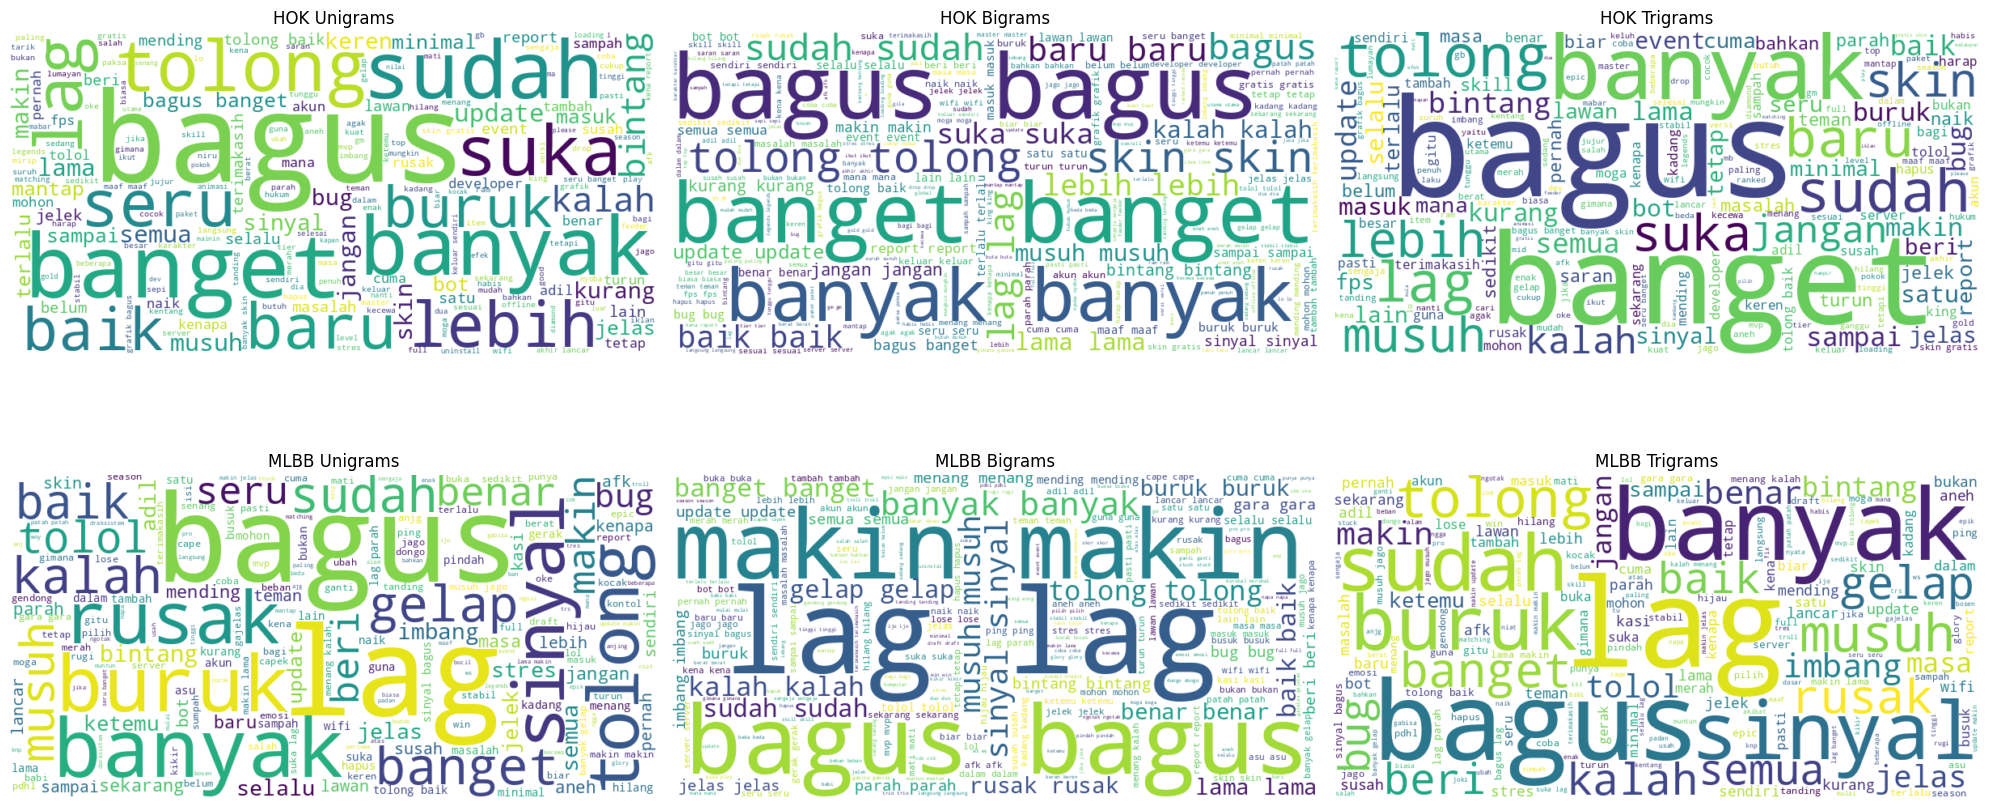

In [34]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Load n-gram data from CSVs
df_hok_unigrams = pd.read_csv('hok_unigrams.csv')
df_hok_bigrams = pd.read_csv('hok_bigrams.csv')
df_hok_trigrams = pd.read_csv('hok_trigrams.csv')

df_mlbb_unigrams = pd.read_csv('mlbb_unigrams.csv')
df_mlbb_bigrams = pd.read_csv('mlbb_bigrams.csv')
df_mlbb_trigrams = pd.read_csv('mlbb_trigrams.csv')


def generate_wordcloud_from_ngrams(df, ngram_col):
    """Generates a word cloud from a DataFrame column containing n-grams."""
    # Flatten the list of lists in the n-gram column and join into a single string
    # Ensure that tokens are strings before joining
    text = ' '.join([' '.join(map(str,ngram)) for ngram_list in df[ngram_col] for ngram in eval(ngram_list) if ngram_list != '[]'])

    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    return wordcloud

# Generate word clouds for HOK n-grams
wordcloud_hok_unigrams = generate_wordcloud_from_ngrams(df_hok_unigrams, 'unigrams_hok')
wordcloud_hok_bigrams = generate_wordcloud_from_ngrams(df_hok_bigrams, 'bigrams_hok')
wordcloud_hok_trigrams = generate_wordcloud_from_ngrams(df_hok_trigrams, 'trigrams_hok')

# Generate word clouds for MLBB n-grams
wordcloud_mlbb_unigrams = generate_wordcloud_from_ngrams(df_mlbb_unigrams, 'unigrams_mlbb')
wordcloud_mlbb_bigrams = generate_wordcloud_from_ngrams(df_mlbb_bigrams, 'bigrams_mlbb')
wordcloud_mlbb_trigrams = generate_wordcloud_from_ngrams(df_mlbb_trigrams, 'trigrams_mlbb')

# Display word clouds
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

axes[0, 0].imshow(wordcloud_hok_unigrams, interpolation='bilinear')
axes[0, 0].axis('off')
axes[0, 0].set_title('HOK Unigrams')

axes[0, 1].imshow(wordcloud_hok_bigrams, interpolation='bilinear')
axes[0, 1].axis('off')
axes[0, 1].set_title('HOK Bigrams')

axes[0, 2].imshow(wordcloud_hok_trigrams, interpolation='bilinear')
axes[0, 2].axis('off')
axes[0, 2].set_title('HOK Trigrams')

axes[1, 0].imshow(wordcloud_mlbb_unigrams, interpolation='bilinear')
axes[1, 0].axis('off')
axes[1, 0].set_title('MLBB Unigrams')

axes[1, 1].imshow(wordcloud_mlbb_bigrams, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('MLBB Bigrams')

axes[1, 2].imshow(wordcloud_mlbb_trigrams, interpolation='bilinear')
axes[1, 2].axis('off')
axes[1, 2].set_title('MLBB Trigrams')

plt.tight_layout()
plt.show()